# Customer-Segmentation-Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Dataset/E-commerce Customer Behavior.csv")

In [3]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
df.shape

(350, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


In [6]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [7]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

#### Data Cleaning

In [11]:
df['Satisfaction Level'] = df['Satisfaction Level'].fillna(df['Satisfaction Level'].mode()[0])

In [12]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64

#### Exploratory Data Analysis (EDA)

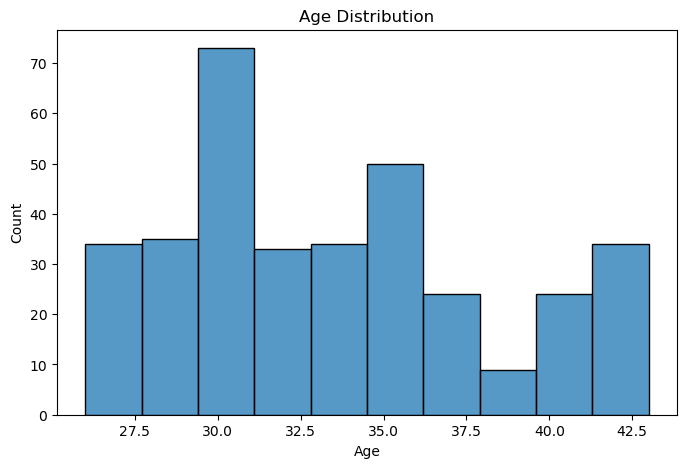

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

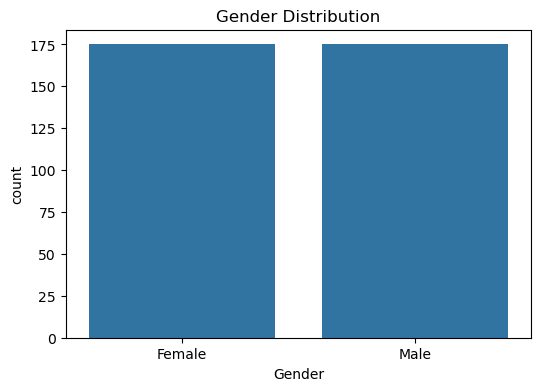

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

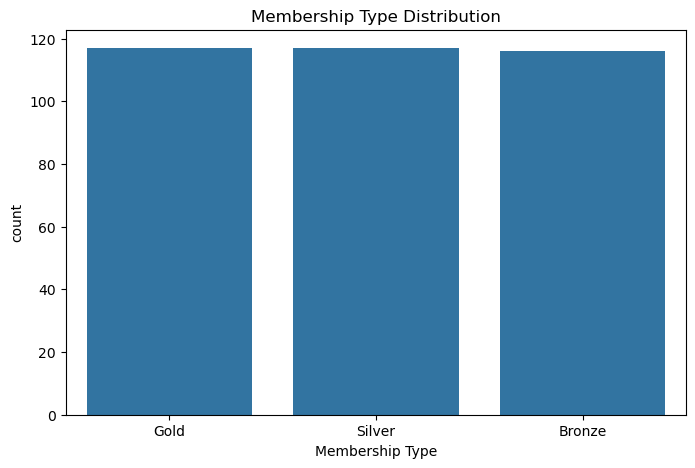

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(x='Membership Type', data=df)

plt.title("Membership Type Distribution")

plt.show()

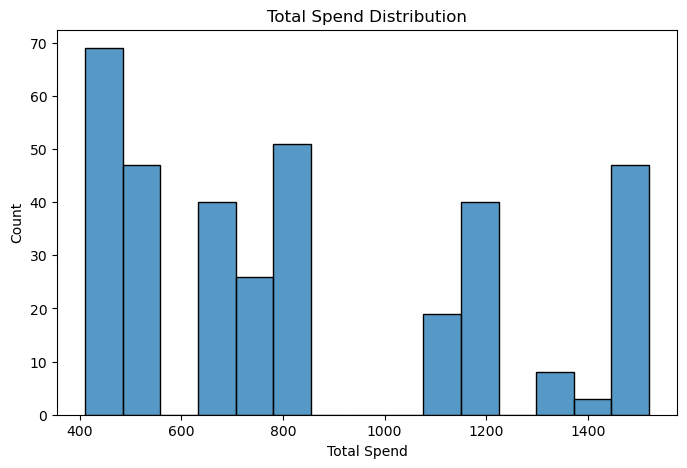

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total Spend'], bins=15)

plt.title("Total Spend Distribution")

plt.xlabel("Total Spend")

plt.show()

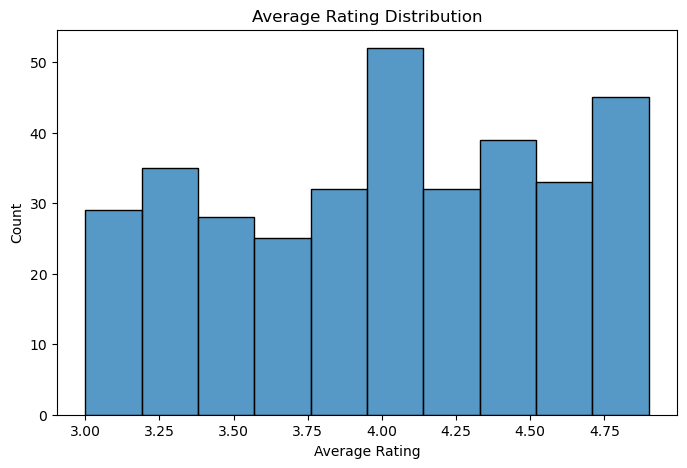

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['Average Rating'], bins=10)

plt.title("Average Rating Distribution")

plt.xlabel("Average Rating")

plt.show()

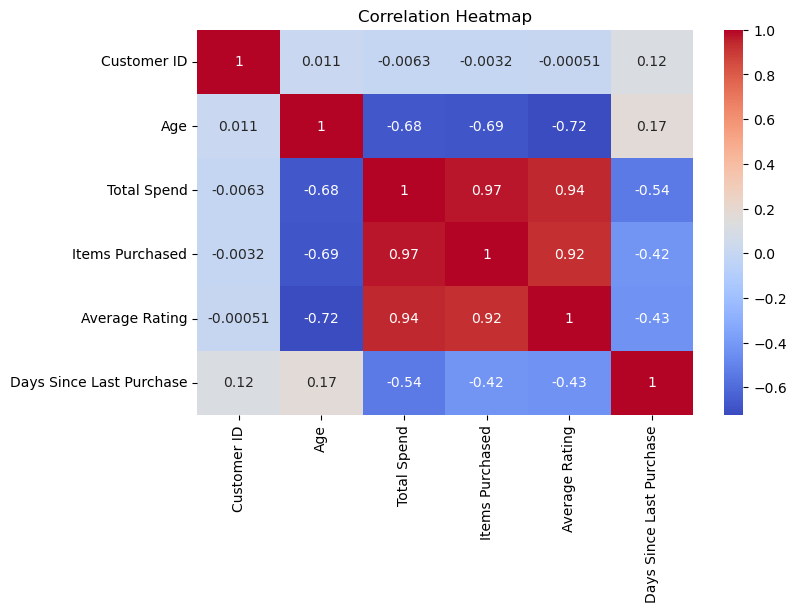

In [19]:
plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

#### # K-Means Clustering

In [27]:
features = df[['Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']]

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [30]:
from sklearn.cluster import KMeans

In [31]:
wcss = []

In [32]:
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

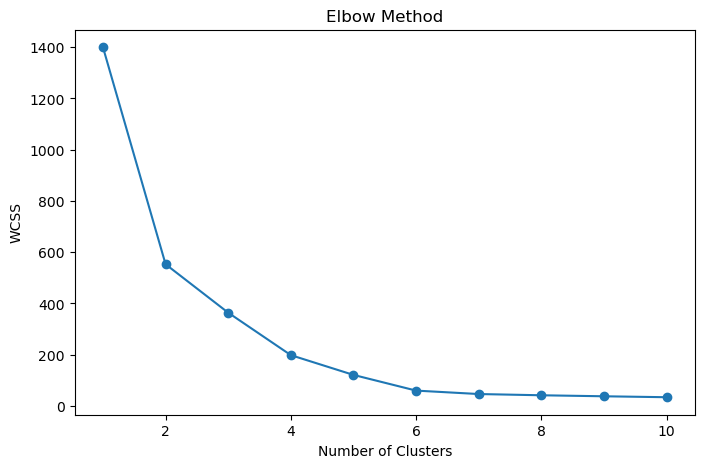

In [33]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [34]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_features)

In [35]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,4
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,3
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,2
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,1
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,2


In [36]:
df['Cluster'].value_counts()

Cluster
2    116
4     59
3     59
1     58
0     58
Name: count, dtype: int64

In [37]:
centroids = kmeans.cluster_centers_

print(centroids)

[[-1.10218973 -1.2122849  -1.42492165 -0.28535728]
 [ 1.69936614  1.78311404  1.36185277 -1.14860819]
 [-0.69216338 -0.49978709 -0.5639065   1.22147802]
 [-0.11033376 -0.22217454  0.26519959 -0.84322186]
 [ 0.88414258  0.64365271  0.90549785 -0.14866718]]


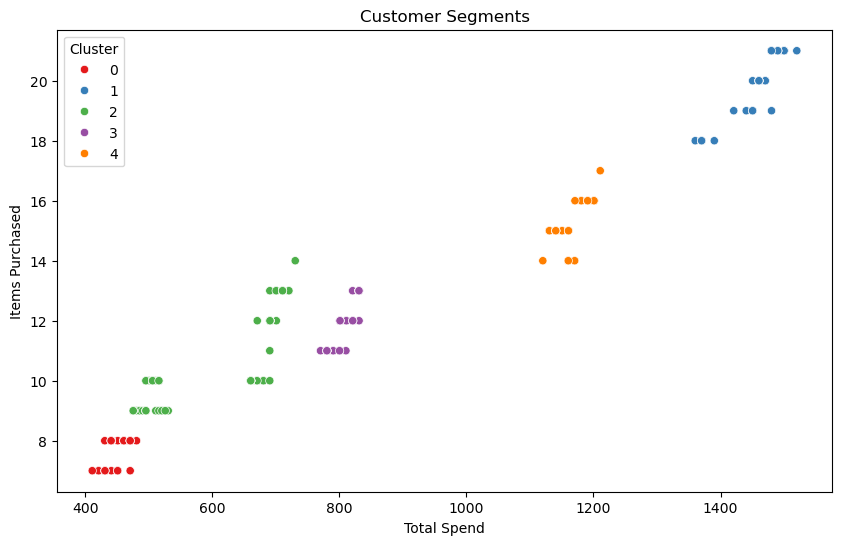

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Total Spend'],
    y=df['Items Purchased'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments")
plt.xlabel("Total Spend")
plt.ylabel("Items Purchased")

plt.show()

Cluster 0 → Low spending low-engagement customers

Cluster 1 → Premium high-value customers

Cluster 2 → Budget-conscious occasional buyers

Cluster 3 → Moderate spending regular customers

Cluster 4 → High spending active customers

In [39]:
df.to_csv("../Dataset/clustered_customers.csv", index=False)

In [40]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,4
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,3
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,2
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,1
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,2
